# Notebook 08: Temporal, regional, subgroup and error analysis

**Objective:** Find where the selected LightGBM model performs differently or fails. Train on dev (2019 to 2021), evaluate on val (2022). Holdout rows (2023 to 2024) are never loaded here.

**Design, fixed before any result in this notebook.**
1. **Temporal.** Model A is LightGBM fitted on 2019 only (pre-COVID), with early stopping on a random 15% of 2019 rows set aside inside the training year. It is scored on 2020, 2021 and 2022, all out-of-sample. Per-year PR-AUC with bootstrap 95% intervals, judged against each year's prevalence. The reference model (fitted on 2019 to 2021, Notebook 04) is scored on 2022 only. Model A against the reference on 2022 is confounded by training size (about 134k against 400k rows). Dev years scored by the dev-fitted model are in-sample and are not reported as robustness evidence.
2. **Regional.** Leave-one-region-out: for each of the 7 regions, fit on dev rows from the other regions (fixed Notebook 04 tree counts) and score val rows from the held-out region, against the reference model on the same rows. The data has no hospital ID, so this tests geography only.
3. **Subgroups** on val 2022 with the reference model: gender, age band, hospital type, region, urban or rural, season, day or night, and the number of the seven selectively ordered labs that are missing (0 to 2, 3 to 4, 5 to 7). A subgroup is reported with conclusions only if it has at least 2,000 rows and at least 100 events. Smaller ones are flagged and not interpreted.
4. **Errors** at a fixed review cut-off: top 20% of scores for adverse_outcome, top 10% for readmission_30d. False positive = reviewed with outcome 0. False negative = not reviewed with outcome 1. Both are compared with correct predictions on the model inputs.
5. All results are associations in synthetic data, not statements about real patients or hospitals.

In [1]:
import time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
import lightgbm as lgb
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss

warnings.filterwarnings("ignore")
targets = ["adverse_outcome", "readmission_30d"]

# ---- data: holdout rows are filtered out at read time ----
pool = pd.read_parquet("../data/interim/model_ready.parquet", filters=[("split", "!=", "holdout")])
feat_tbl = pd.read_csv("../reports/tables/feature_summary.csv")
features = feat_tbl["feature"].tolist()
cat_features = feat_tbl.loc[feat_tbl["kind"] == "categorical", "feature"].tolist()
assert not {"arrival_day", "arrival_month", "arrival_day_of_week", "arrival_year"} & set(features)

dev = pool[pool["split"] == "dev"].reset_index(drop=True)
val = pool[pool["split"] == "val"].reset_index(drop=True)

# =============== SHARED FUNCTIONS (copied from Notebooks 04 and 07) ===============
def to_cat(d):
    X = d[features].copy()
    for c in cat_features:
        X[c] = X[c].astype(pd.CategoricalDtype(sorted(dev[c].unique())))
    return X

def ece_score(y, p, n_bins=10):
    bins = np.minimum((p * n_bins).astype(int), n_bins - 1)
    return sum((bins == b).mean() * abs(p[bins == b].mean() - y[bins == b].mean())
               for b in range(n_bins) if (bins == b).any())

def ap_ci(y, p, n=200, seed=0):
    rs = np.random.default_rng(seed)
    y, p = np.asarray(y), np.asarray(p)
    vals = []
    for _ in range(n):
        i = rs.integers(0, len(y), len(y))
        vals.append(average_precision_score(y[i], p[i]))
    return np.percentile(vals, [2.5, 97.5])

def paired_boot(y, p_a, p_b, n=200, seed=0):
    rs = np.random.default_rng(seed)
    y, p_a, p_b = np.asarray(y), np.asarray(p_a), np.asarray(p_b)
    diffs = []
    for _ in range(n):
        i = rs.integers(0, len(y), len(y))
        diffs.append(average_precision_score(y[i], p_b[i]) - average_precision_score(y[i], p_a[i]))
    return np.percentile(diffs, [2.5, 50, 97.5]).round(4)

def rank_table(y, score, ks, seed=42):
    y, score = np.asarray(y), np.asarray(score)
    jitter = np.random.default_rng(seed).random(len(score)) * 1e-9
    order = np.argsort(-(score + jitter))
    total, prev, rows = int(y.sum()), y.mean(), []
    for k in ks:
        n = int(round(len(y) * k))
        hits = int(y[order[:n]].sum())
        rows.append({"K": k, "n_review": n, "events_captured": hits, "total_events": total,
                     "recall": hits / total, "precision": hits / n,
                     "lift": (hits / n) / y.mean(), "false_positives": n - hits})
    return pd.DataFrame(rows)
# ==================================================================================

# ---- reference model: LightGBM refit on dev with the Notebook 04 settings ----
PARAMS = dict(learning_rate=0.05, num_leaves=31, min_child_samples=20, subsample=0.8,
              subsample_freq=1, colsample_bytree=0.8, n_jobs=-1, random_state=42, verbose=-1)
TREES = {"adverse_outcome": 291, "readmission_30d": 51}

Xdev, Xval = to_cat(dev), to_cat(val)
vp = pd.read_parquet("../data/interim/val_predictions_classical.parquet")
assert (vp["encounter_id"].values == val["encounter_id"].values).all(), "row order differs"

models, p_val = {}, {}
for t in targets:
    t0 = time.time()
    m = lgb.LGBMClassifier(n_estimators=TREES[t], **PARAMS).fit(Xdev, dev[t])
    models[t], p_val[t] = m, m.predict_proba(Xval)[:, 1]
    saved = vp[f"lightgbm_{t}"].values
    print(t, "| refit val PR-AUC:", round(average_precision_score(val[t], p_val[t]), 4),
          "| saved:", round(average_precision_score(val[t], saved), 4),
          "| max abs diff:", float(np.abs(p_val[t] - saved).max()),
          "| seconds:", round(time.time() - t0))

print()
print(pool.groupby("arrival_year").agg(rows=("encounter_id", "size"),
                                       adverse_outcome=("adverse_outcome", "mean"),
                                       readmission_30d=("readmission_30d", "mean")).round(4))
print("splits present:", sorted(pool["split"].unique()))
print("years present:", sorted(int(y) for y in pool["arrival_year"].unique()))

adverse_outcome | refit val PR-AUC: 0.7553 | saved: 0.7553 | max abs diff: 0.0 | seconds: 6
readmission_30d | refit val PR-AUC: 0.2138 | saved: 0.2138 | max abs diff: 0.0 | seconds: 2

                rows  adverse_outcome  readmission_30d
arrival_year                                          
2019          133816           0.4083           0.1381
2020          133486           0.4092           0.1368
2021          133063           0.4103           0.1381
2022          133853           0.4080           0.1360
splits present: ['dev', 'val']
years present: [2019, 2020, 2021, 2022]


2019 training rows: 113818 | early-stopping rows: 19998
adverse_outcome | Model A trees: 140 | seconds: 4
readmission_30d | Model A trees: 31 | seconds: 2

         target                 model                 year      n  prevalence  pr_auc  pr_ci_low  pr_ci_high  roc_auc  brier
adverse_outcome         A (2019 only) 2019 early-stop rows  19998      0.4122  0.7499     0.7414      0.7601   0.7970 0.1777
adverse_outcome         A (2019 only)                 2020 133486      0.4092  0.7502     0.7468      0.7536   0.8008 0.1757
adverse_outcome         A (2019 only)                 2021 133063      0.4103  0.7537     0.7502      0.7579   0.8014 0.1755
adverse_outcome         A (2019 only)                 2022 133853      0.4080  0.7526     0.7492      0.7562   0.8023 0.1749
adverse_outcome reference (2019-2021)                 2022 133853      0.4080  0.7553     0.7519      0.7584   0.8041 0.1740
readmission_30d         A (2019 only) 2019 early-stop rows  19998      0.1366  0.2174     0.20

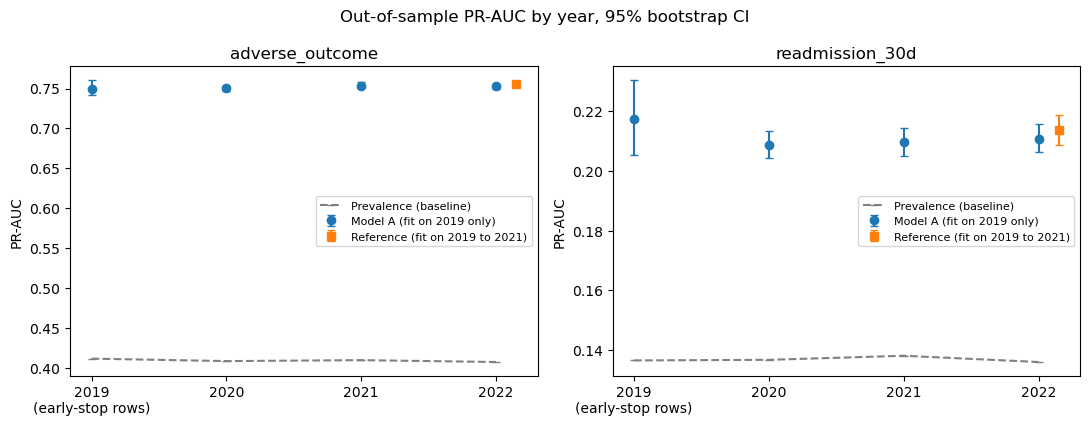

tables/temporal_regime_results.csv | KB: 1.3
figures/temporal_performance.png | KB: 71.3


In [2]:
import matplotlib.pyplot as plt
tables = Path("../reports/tables"); tables.mkdir(parents=True, exist_ok=True)
figs = Path("../reports/figures"); figs.mkdir(parents=True, exist_ok=True)

d19 = dev[dev["arrival_year"] == 2019]
is_es = np.random.default_rng(42).random(len(d19)) < 0.15
tr19, es19 = d19[~is_es], d19[is_es]
print("2019 training rows:", len(tr19), "| early-stopping rows:", len(es19))

rows, modelA, pA = [], {}, {}
def add_row(t, model, year, d, p, note):
    y = d[t].values
    lo, hi = ap_ci(y, p)
    rows.append({"target": t, "model": model, "year": year, "n": len(y), "prevalence": y.mean(),
                 "pr_auc": average_precision_score(y, p), "pr_ci_low": lo, "pr_ci_high": hi,
                 "roc_auc": roc_auc_score(y, p), "brier": brier_score_loss(y, p),
                 "ece": ece_score(y, p), "note": note})

for t in targets:
    t0 = time.time()
    m = lgb.LGBMClassifier(n_estimators=2000, **PARAMS)
    m.fit(to_cat(tr19), tr19[t], eval_set=[(to_cat(es19), es19[t])], eval_metric="average_precision",
          callbacks=[lgb.early_stopping(50, verbose=False)])
    modelA[t] = m
    print(t, "| Model A trees:", m.best_iteration_, "| seconds:", round(time.time() - t0))
    add_row(t, "A (2019 only)", "2019 early-stop rows", es19, m.predict_proba(to_cat(es19))[:, 1],
            "used for early stopping, slightly optimistic")
    for yr in [2020, 2021]:
        d = dev[dev["arrival_year"] == yr]
        pA[(t, yr)] = m.predict_proba(to_cat(d))[:, 1]
        add_row(t, "A (2019 only)", yr, d, pA[(t, yr)], "out-of-sample")
    pA[(t, 2022)] = m.predict_proba(Xval)[:, 1]
    add_row(t, "A (2019 only)", 2022, val, pA[(t, 2022)], "out-of-sample")
    add_row(t, "reference (2019-2021)", 2022, val, p_val[t], "out-of-sample, about 3x the training rows")

res = pd.DataFrame(rows)
res.round(4).to_csv(tables / "temporal_regime_results.csv", index=False)
print()
print(res[["target", "model", "year", "n", "prevalence", "pr_auc", "pr_ci_low", "pr_ci_high",
           "roc_auc", "brier"]].round(4).to_string(index=False))
print()
for t in targets:
    print(t, "reference minus Model A on 2022 [2.5%, median, 97.5%]:",
          paired_boot(val[t], pA[(t, 2022)], p_val[t]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, t in zip(axes, targets):
    s = res[res["target"] == t]
    a = s[s["model"] == "A (2019 only)"].reset_index(drop=True)
    x = np.arange(len(a))
    ax.errorbar(x, a["pr_auc"], yerr=[a["pr_auc"] - a["pr_ci_low"], a["pr_ci_high"] - a["pr_auc"]],
                fmt="o", capsize=3, label="Model A (fit on 2019 only)")
    r = s[s["model"] == "reference (2019-2021)"].iloc[0]
    ax.errorbar([x[-1] + 0.15], [r["pr_auc"]],
                yerr=[[r["pr_auc"] - r["pr_ci_low"]], [r["pr_ci_high"] - r["pr_auc"]]],
                fmt="s", capsize=3, label="Reference (fit on 2019 to 2021)")
    ax.plot(x, a["prevalence"], "--", color="grey", marker="_", label="Prevalence (baseline)")
    ax.set_xticks(x)
    ax.set_xticklabels([str(v).replace(" early-stop rows", "\n(early-stop rows)") for v in a["year"]])
    ax.set_ylabel("PR-AUC"); ax.set_title(t); ax.legend(fontsize=8)
fig.suptitle("Out-of-sample PR-AUC by year, 95% bootstrap CI")
fig.tight_layout()
plt.savefig(figs / "temporal_performance.png", dpi=150, bbox_inches="tight")
plt.show()

for f in ["tables/temporal_regime_results.csv", "figures/temporal_performance.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

In [3]:
region_col = "nuts2_region"
regions = sorted(dev[region_col].unique())
print("regions in dev:", regions)
print("rows per region in val:", val[region_col].value_counts().to_dict())

lo_rows, preds_lo = [], {}
for t in targets:
    for r in regions:
        tr = dev[dev[region_col] != r]
        m = lgb.LGBMClassifier(n_estimators=TREES[t], **PARAMS).fit(to_cat(tr), tr[t])
        mask = (val[region_col] == r).values
        y = val.loc[mask, t].values
        p_lo = m.predict_proba(Xval[mask])[:, 1]
        p_ref = p_val[t][mask]
        preds_lo[(t, r)] = p_lo
        small = (mask.sum() < 2000) or (y.sum() < 100)
        ci = paired_boot(y, p_ref, p_lo) if not small else np.array([np.nan] * 3)
        lo_rows.append({"target": t, "held_out_region": r, "n_val": int(mask.sum()), "events": int(y.sum()),
                        "prevalence": y.mean(), "pr_auc_heldout": average_precision_score(y, p_lo),
                        "pr_auc_reference": average_precision_score(y, p_ref),
                        "diff_ci_low": ci[0], "diff_median": ci[1], "diff_ci_high": ci[2],
                        "small_group": small})
    print(t, "done")

lo = pd.DataFrame(lo_rows)
lo["diff_point"] = lo["pr_auc_heldout"] - lo["pr_auc_reference"]
lo.round(4).to_csv(tables / "leave_one_region_out.csv", index=False)
print()
print(lo[["target", "held_out_region", "n_val", "events", "prevalence", "pr_auc_heldout", "pr_auc_reference",
          "diff_point", "diff_ci_low", "diff_ci_high", "small_group"]].round(4).to_string(index=False))

p = tables / "leave_one_region_out.csv"
print("leave_one_region_out.csv | KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

regions in dev: ['Aegean', 'Black Sea', 'Central Anatolia', 'Eastern Anatolia', 'Marmara', 'Mediterranean', 'Southeastern Anatolia']
rows per region in val: {'Marmara': 51898, 'Central Anatolia': 21000, 'Mediterranean': 18807, 'Aegean': 17441, 'Southeastern Anatolia': 13824, 'Eastern Anatolia': 6055, 'Black Sea': 4828}
adverse_outcome done
readmission_30d done

         target       held_out_region  n_val  events  prevalence  pr_auc_heldout  pr_auc_reference  diff_point  diff_ci_low  diff_ci_high  small_group
adverse_outcome                Aegean  17441    7079      0.4059          0.7534            0.7537     -0.0003      -0.0012        0.0008        False
adverse_outcome             Black Sea   4828    1985      0.4111          0.7538            0.7538      0.0000      -0.0020        0.0019        False
adverse_outcome      Central Anatolia  21000    8589      0.4090          0.7531            0.7532     -0.0001      -0.0010        0.0007        False
adverse_outcome      Eastern Ana

adverse_outcome done
readmission_30d done

adverse_outcome | review cut-off: top 20 % of val scores
     variable                          group      n  events  prevalence  pr_auc  pr_ci_low  pr_ci_high  pr_over_prev  roc_auc  roc_ci_low  roc_ci_high  flagged_share  precision  recall  small_group
      overall                   all val 2022 133853   54615      0.4080  0.7553     0.7519      0.7584        1.8510   0.8041      0.8017       0.8065         0.2000     0.8213  0.4026        False
       gender                         Female  65791   24167      0.3673  0.7299     0.7244      0.7358        1.9870   0.8064      0.8031       0.8098         0.1661     0.8138  0.3680        False
       gender                           Male  68062   30448      0.4474  0.7740     0.7698      0.7788        1.7301   0.7973      0.7941       0.8012         0.2328     0.8264  0.4300        False
    age_group                        Neonate   2348     643      0.2739  0.5903     0.5520      0.6299      

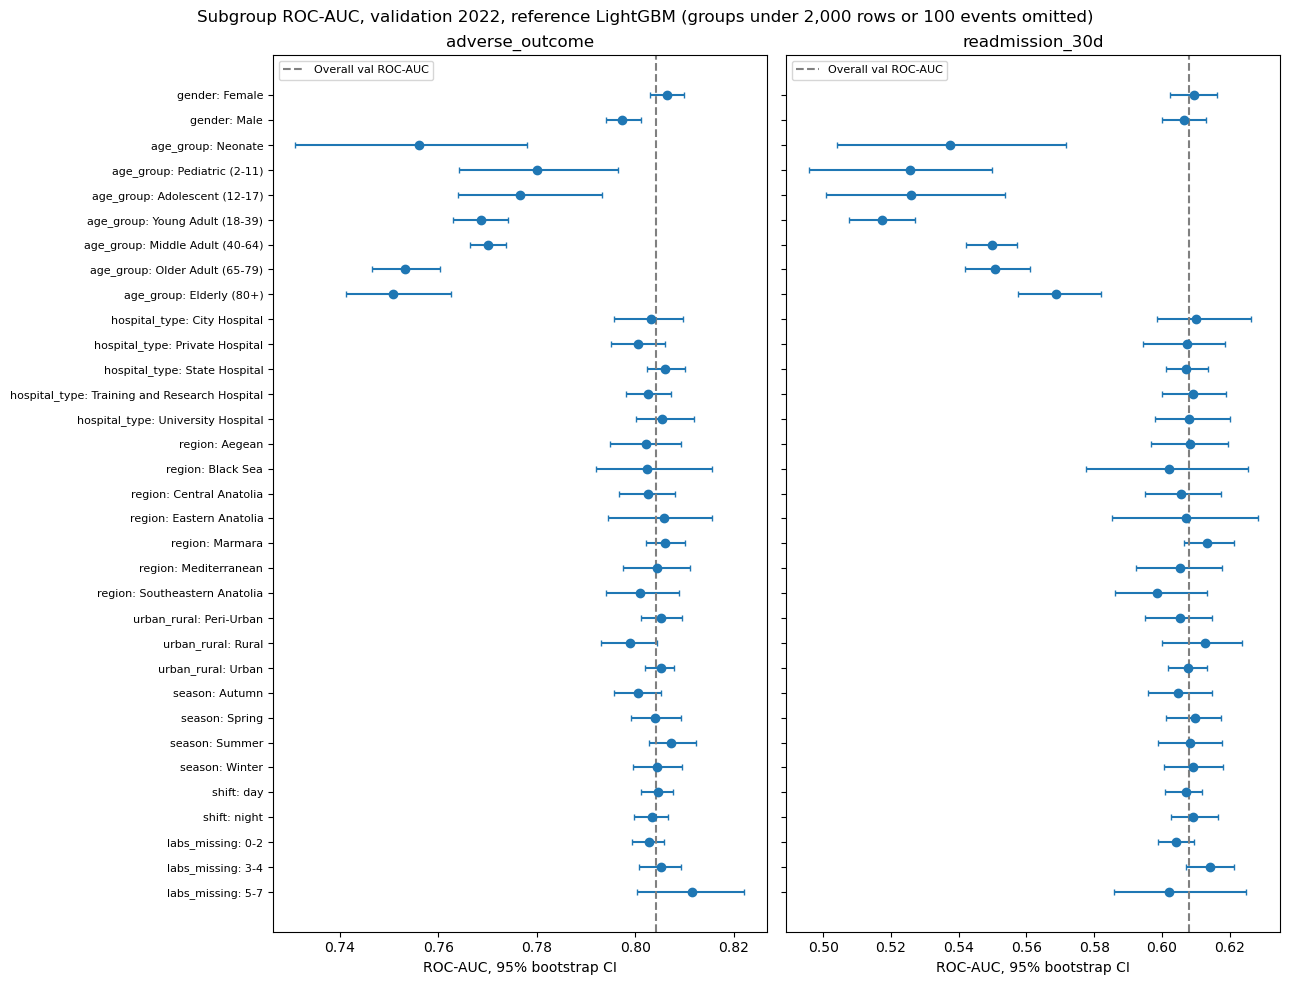

tables/subgroup_results.csv | KB: 9.0
figures/subgroup_performance.png | KB: 194.6


In [4]:
lab7 = ["troponin_i_ngml", "bnp_pgl", "d_dimer_mgfl", "lactate_mmoll",
        "lipase_ul", "procalcitonin_ngl", "albumin_gdl"]

sg = val.copy()
sg["lab_missing_n"] = pd.cut(sg[lab7].isna().sum(axis=1), bins=[-1, 2, 4, 7], labels=["0-2", "3-4", "5-7"])
sg["shift"] = np.where(sg["is_night_shift"] == 1, "night", "day")
age_order = sg.groupby("age_group")["age"].mean().sort_values().index.tolist()

VARS = [("gender", "gender"), ("age_group", "age_group"), ("hospital_type", "hospital_type"),
        ("region", "nuts2_region"), ("urban_rural", "urban_rural"), ("season", "arrival_season"),
        ("shift", "shift"), ("labs_missing", "lab_missing_n")]
REVIEW_Q = {"adverse_outcome": 0.20, "readmission_30d": 0.10}

def boot_both(y, p, n=200, seed=0):
    rs = np.random.default_rng(seed)
    ap, roc = [], []
    for _ in range(n):
        i = rs.integers(0, len(y), len(y))
        ap.append(average_precision_score(y[i], p[i]))
        roc.append(roc_auc_score(y[i], p[i]))
    return np.percentile(ap, [2.5, 97.5]), np.percentile(roc, [2.5, 97.5])

def one_row(t, var, group, y, p, fl):
    small = (len(y) < 2000) or (y.sum() < 100)
    valid = 0 < y.sum() < len(y)
    if valid and not small:
        a, r = boot_both(y, p)
    else:
        a, r = (np.nan, np.nan), (np.nan, np.nan)
    pr = average_precision_score(y, p) if valid else np.nan
    return {"target": t, "variable": var, "group": group, "n": len(y), "events": int(y.sum()),
            "prevalence": y.mean(), "pr_auc": pr, "pr_ci_low": a[0], "pr_ci_high": a[1],
            "pr_over_prev": pr / y.mean() if valid else np.nan,
            "roc_auc": roc_auc_score(y, p) if valid else np.nan, "roc_ci_low": r[0], "roc_ci_high": r[1],
            "flagged_share": fl.mean(),
            "precision": y[fl].mean() if fl.sum() else np.nan,
            "recall": y[fl].sum() / y.sum() if y.sum() else np.nan,
            "small_group": small}

rows, roc_overall = [], {}
for t in targets:
    y_all, p_all = val[t].values, p_val[t]
    fl_all = p_all >= np.quantile(p_all, 1 - REVIEW_Q[t])
    roc_overall[t] = roc_auc_score(y_all, p_all)
    rows.append(one_row(t, "overall", "all val 2022", y_all, p_all, fl_all))
    for var, col in VARS:
        levels = age_order if var == "age_group" else sorted(sg[col].dropna().unique(), key=str)
        for g in levels:
            m = (sg[col] == g).values
            rows.append(one_row(t, var, g, y_all[m], p_all[m], fl_all[m]))
    print(t, "done")

sg_res = pd.DataFrame(rows)
sg_res.round(4).to_csv(tables / "subgroup_results.csv", index=False)

show = ["variable", "group", "n", "events", "prevalence", "pr_auc", "pr_ci_low", "pr_ci_high",
        "pr_over_prev", "roc_auc", "roc_ci_low", "roc_ci_high", "flagged_share", "precision", "recall",
        "small_group"]
for t in targets:
    print()
    print(t, "| review cut-off: top", int(REVIEW_Q[t] * 100), "% of val scores")
    print(sg_res[sg_res["target"] == t][show].round(4).to_string(index=False))

# ---- forest plot: ROC-AUC by group ----
fig, axes = plt.subplots(1, 2, figsize=(13, 10), sharey=True)
for ax, t in zip(axes, targets):
    s = sg_res[(sg_res["target"] == t) & (sg_res["variable"] != "overall")].reset_index(drop=True)
    ypos = np.arange(len(s))[::-1]
    ok = (~s["small_group"]).values
    ax.errorbar(s.loc[ok, "roc_auc"], ypos[ok],
                xerr=[(s.loc[ok, "roc_auc"] - s.loc[ok, "roc_ci_low"]).values,
                      (s.loc[ok, "roc_ci_high"] - s.loc[ok, "roc_auc"]).values],
                fmt="o", capsize=2)
    ax.axvline(roc_overall[t], color="grey", ls="--", label="Overall val ROC-AUC")
    ax.set_title(t); ax.set_xlabel("ROC-AUC, 95% bootstrap CI"); ax.legend(fontsize=8)
axes[0].set_yticks(ypos)
axes[0].set_yticklabels([f"{v}: {g}" for v, g in zip(s["variable"], s["group"])], fontsize=8)
fig.suptitle("Subgroup ROC-AUC, validation 2022, reference LightGBM (groups under 2,000 rows or 100 events omitted)")
fig.tight_layout()
plt.savefig(figs / "subgroup_performance.png", dpi=150, bbox_inches="tight")
plt.show()

for f in ["tables/subgroup_results.csv", "figures/subgroup_performance.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

In [5]:
sg_res = pd.read_csv("../reports/tables/subgroup_results.csv")
overall = sg_res[sg_res["variable"] == "overall"].set_index("target")["roc_auc"]

for t in targets:
    s = sg_res[(sg_res["target"] == t) & (sg_res["variable"] != "overall")].copy()
    s["roc_vs_overall"] = np.where(s["small_group"], "small",
                          np.where(s["roc_ci_high"] < overall[t], "below",
                          np.where(s["roc_ci_low"] > overall[t], "above", "in line")))
    print(t, "| overall ROC-AUC:", round(overall[t], 4))
    print(s[["variable", "group", "n", "events", "prevalence", "roc_auc", "roc_ci_low", "roc_ci_high",
             "roc_vs_overall", "flagged_share", "recall"]].round(3).to_string(index=False))
    print(s["roc_vs_overall"].value_counts().to_dict())
    print()

for f in ["tables/subgroup_results.csv", "figures/subgroup_performance.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

adverse_outcome | overall ROC-AUC: 0.8041
     variable                          group     n  events  prevalence  roc_auc  roc_ci_low  roc_ci_high roc_vs_overall  flagged_share  recall
       gender                         Female 65791   24167       0.367    0.806       0.803        0.810        in line          0.166   0.368
       gender                           Male 68062   30448       0.447    0.797       0.794        0.801          below          0.233   0.430
    age_group                        Neonate  2348     643       0.274    0.756       0.731        0.778          below          0.067   0.204
    age_group               Pediatric (2-11)  4250    1153       0.271    0.780       0.764        0.796          below          0.070   0.215
    age_group             Adolescent (12-17)  4572    1290       0.282    0.776       0.764        0.793          below          0.072   0.206
    age_group            Young Adult (18-39) 35816    9770       0.273    0.769       0.763        0

adverse_outcome | age alone: ROC-AUC 0.6734 | PR-AUC 0.6061 || LightGBM: ROC-AUC 0.8041 | PR-AUC 0.7553 | prevalence 0.408
   LightGBM minus age alone, PR-AUC [2.5%, median, 97.5%]: [0.1461 0.1495 0.1524]
readmission_30d | age alone: ROC-AUC 0.6019 | PR-AUC 0.2107 || LightGBM: ROC-AUC 0.608 | PR-AUC 0.2138 | prevalence 0.136
   LightGBM minus age alone, PR-AUC [2.5%, median, 97.5%]: [0.002  0.0031 0.0045]

adverse_outcome | review top 20 % | reviewed: 26771 | counts: {'TN': 74453, 'FN': 32629, 'TP': 21986, 'FP': 4785}
   precision 0.8213 | recall 0.4026 | false positive rate 0.0604
  FP vs TP (both reviewed) | n = 4785 vs 21986 | features with |SMD| > 0.1: 20 of 85
                     smd  mean FP  mean TP
model_score       -0.685    0.775    0.828
triage_level       0.228    2.808    2.580
sofa_score_approx -0.224    5.196    5.636
gcs_total          0.216   10.733   10.336
mews_score        -0.204    4.715    5.103
news2_score       -0.198    7.152    7.663
pain_score_nrs    -0.158 

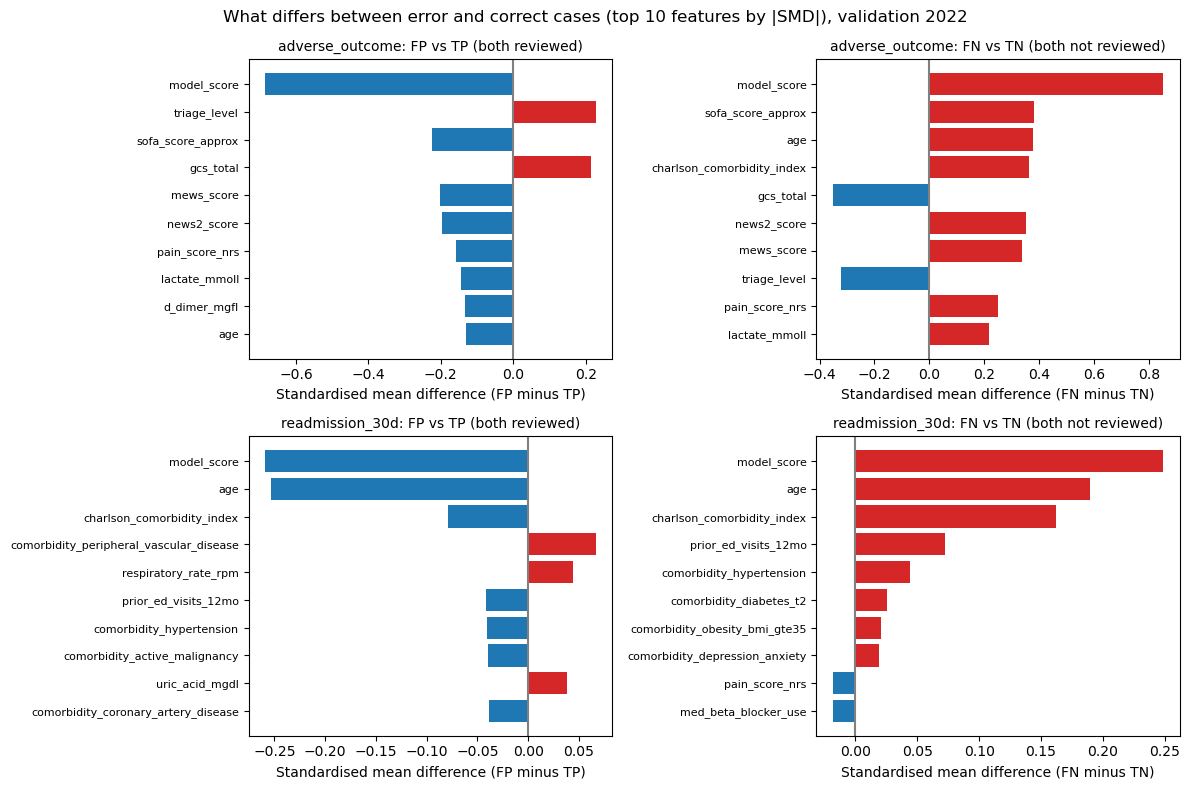

tables/error_analysis.csv | KB: 32.3
figures/error_profiles.png | KB: 166.5


In [7]:
# ---- one-feature reference: age alone on val ----
for t in targets:
    y = val[t].values
    print(t, "| age alone: ROC-AUC", round(roc_auc_score(y, val["age"]), 4),
          "| PR-AUC", round(average_precision_score(y, val["age"]), 4),
          "|| LightGBM: ROC-AUC", round(roc_auc_score(y, p_val[t]), 4),
          "| PR-AUC", round(average_precision_score(y, p_val[t]), 4),
          "| prevalence", round(y.mean(), 4))
    print("   LightGBM minus age alone, PR-AUC [2.5%, median, 97.5%]:",
          paired_boot(y, val["age"].values.astype(float), p_val[t]))
print()

# ---- error analysis ----
nb = feat_tbl.loc[feat_tbl["kind"].isin(["numeric", "binary"]), "feature"].tolist()
REVIEW_Q = {"adverse_outcome": 0.20, "readmission_30d": 0.10}
COMPARE = [("FP", "TP", "FP vs TP (both reviewed)"), ("FN", "TN", "FN vs TN (both not reviewed)")]

err_rows, plots = [], {}
for t in targets:
    y, p = val[t].values, p_val[t]
    fl = p >= np.quantile(p, 1 - REVIEW_Q[t])
    grp = np.select([fl & (y == 1), fl & (y == 0), ~fl & (y == 1), ~fl & (y == 0)],
                    ["TP", "FP", "FN", "TN"], default="NA")
    assert not (grp == "NA").any()
    cnt = pd.Series(grp).value_counts()
    print(t, "| review top", int(REVIEW_Q[t] * 100), "% | reviewed:", int(fl.sum()), "| counts:", cnt.to_dict())
    print("   precision", round(cnt["TP"] / (cnt["TP"] + cnt["FP"]), 4),
          "| recall", round(cnt["TP"] / (cnt["TP"] + cnt["FN"]), 4),
          "| false positive rate", round(cnt["FP"] / (cnt["FP"] + cnt["TN"]), 4))

    X = val[nb].copy()
    X["gender_male"] = (val["gender"] == "Male").astype(int)
    X["model_score"] = p
    for a, b, label in COMPARE:
        A, B = X[grp == a], X[grp == b]
        sd = np.sqrt((A.var() + B.var()) / 2)
        d = ((A.mean() - B.mean()) / sd).replace([np.inf, -np.inf], np.nan).dropna()
        d = d.reindex(d.abs().sort_values(ascending=False).index)
        plots[(t, label)] = d.head(10)
        print(f"  {label} | n = {len(A)} vs {len(B)} | features with |SMD| > 0.1: {int((d.abs() > 0.1).sum())} of {len(d)}")
        top = d.head(8)
        print(pd.DataFrame({"smd": top.round(3), f"mean {a}": A[top.index].mean().round(3),
                            f"mean {b}": B[top.index].mean().round(3)}).to_string())
        for f_, v in d.items():
            err_rows.append({"target": t, "comparison": label, "feature": f_, "smd": v,
                             "mean_first": A[f_].mean(), "mean_second": B[f_].mean(),
                             "n_first": len(A), "n_second": len(B)})
    print()

pd.DataFrame(err_rows).round(4).to_csv(tables / "error_analysis.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for r, t in enumerate(targets):
    for c, (a, b, label) in enumerate(COMPARE):
        d = plots[(t, label)]
        ax = axes[r, c]
        ax.barh(d.index[::-1], d.values[::-1], color=["tab:red" if v > 0 else "tab:blue" for v in d.values[::-1]])
        ax.axvline(0, color="grey")
        ax.set_title(f"{t}: {label}", fontsize=10)
        ax.set_xlabel(f"Standardised mean difference ({a} minus {b})")
        ax.tick_params(axis="y", labelsize=8)
fig.suptitle("What differs between error and correct cases (top 10 features by |SMD|), validation 2022")
fig.tight_layout()
plt.savefig(figs / "error_profiles.png", dpi=150, bbox_inches="tight")
plt.show()

for f in ["tables/error_analysis.csv", "figures/error_profiles.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

In [8]:
for f in ["tables/temporal_regime_results.csv", "figures/temporal_performance.png",
          "tables/leave_one_region_out.csv", "tables/subgroup_results.csv",
          "figures/subgroup_performance.png", "tables/error_analysis.csv",
          "figures/error_profiles.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")
print("splits present:", sorted(pool["split"].unique()))

tables/temporal_regime_results.csv | KB: 1.3
figures/temporal_performance.png | KB: 71.3
tables/leave_one_region_out.csv | KB: 1.5
tables/subgroup_results.csv | KB: 9.0
figures/subgroup_performance.png | KB: 194.6
tables/error_analysis.csv | KB: 32.3
figures/error_profiles.png | KB: 166.5
splits present: ['dev', 'val']


## Setup
Train on dev (2019 to 2021). Evaluate on val (2022). Holdout rows were filtered out at read time and never loaded. The reference LightGBM refit matches Notebook 04 exactly (max prediction difference 0.0, val PR-AUC 0.7553 and 0.2138). All results are associations in synthetic data, not statements about real patients or hospitals.

## Temporal (reports/tables/temporal_regime_results.csv, figures/temporal_performance.png)
Design fixed before any result: Model A is LightGBM fitted on 2019 only (113,818 training rows, 19,998 rows held out for early stopping, 140 trees for adverse_outcome and 31 for readmission_30d), scored on 2020, 2021 and 2022, all out-of-sample. Dev years scored by the dev-fitted model are in-sample and are not reported as robustness evidence.

PR-AUC with 95% bootstrap interval:

| Year | adverse_outcome | readmission_30d |
|---|---|---|
| 2019 early-stopping rows (slightly optimistic) | 0.7499 (0.7414 to 0.7601) | 0.2174 (0.2054 to 0.2304) |
| 2020, Model A | 0.7502 (0.7468 to 0.7536) | 0.2088 (0.2042 to 0.2135) |
| 2021, Model A | 0.7537 (0.7502 to 0.7579) | 0.2096 (0.2051 to 0.2146) |
| 2022, Model A | 0.7526 (0.7492 to 0.7562) | 0.2108 (0.2062 to 0.2156) |
| 2022, reference (fit 2019 to 2021) | 0.7553 (0.7519 to 0.7584) | 0.2138 (0.2089 to 0.2187) |

- Prevalence is flat across years (adverse_outcome 0.408 to 0.410, readmission_30d 0.136 to 0.138).
- Reference minus Model A on 2022: +0.0027 (0.0021 to 0.0032) for adverse_outcome and +0.0031 (0.0014 to 0.0045) for readmission_30d. This is confounded by training size (400,365 against 113,818 rows) and does not measure COVID shift.
- No sign of COVID-era degradation in 2020 and 2021. This agrees with the Notebook 02 drift test. Limit: one training year, and excluded columns such as covid_tested were not examined.

## Leave-one-region-out (reports/tables/leave_one_region_out.csv)
For each of 7 regions, LightGBM fitted on dev rows from the other 6 regions (Notebook 04 tree counts) and scored on val rows from the held-out region, with a paired bootstrap against the reference model on the same rows.
- All 14 intervals include zero. No group was small (smallest: Black Sea, 4,828 val rows, 1,985 and 662 events).
- Largest point gaps (held-out minus reference): adverse_outcome Southeastern Anatolia -0.0007 (-0.0018 to 0.0005). readmission_30d Southeastern Anatolia -0.0030 (-0.0063 to 0.0003) and Eastern Anatolia -0.0023 (-0.0068 to 0.0044).
- Limits: the categorical type was built from all dev cities, so how LightGBM routes the held-out region's cities was not verified. The data has no hospital ID, so this tests geography only.

## Subgroups (reports/tables/subgroup_results.csv, figures/subgroup_performance.png)
Reference model on val 2022. Review cut-off: top 20% of val scores for adverse_outcome, top 10% for readmission_30d. Groups under 2,000 rows or 100 events get no interval. 33 groups for each of two targets (66 intervals), so about 3 will miss the overall line by chance. This is a screen, not a test.
- Hospital type, region, urban or rural, season, day or night and number of missing labs: every ROC-AUC interval includes the overall value. Ranges: adverse_outcome 0.799 to 0.812, readmission_30d 0.598 to 0.614.
- The age-group and male rows were labelled "below" overall by my comparison rule. That rule is misleading: stratified AUC drops when between-age pairs are removed. Compare groups with each other, not with the pooled value.
- Gender, adverse_outcome: ROC-AUC female 0.806 (0.803 to 0.810), male 0.797 (0.794 to 0.801). Prevalence 0.367 and 0.447. At the shared cut-off the model flags 23.3% of males and 16.6% of females, with recall 0.430 and 0.368 and precision 0.826 and 0.814. This follows from gender being a model input (Notebook 07).
- Age group, adverse_outcome ROC-AUC: neonate 0.756, pediatric 0.780, adolescent 0.776, young adult 0.769, middle adult 0.770, older adult 0.753, elderly 0.751.
- Age group, readmission_30d ROC-AUC: neonate 0.538, pediatric 0.526, adolescent 0.526, young adult 0.517, middle adult 0.550, older adult 0.551, elderly 0.569. At the top-10% cut-off the flagged share is 0.000 for every group under 65, 0.160 for ages 65 to 79 and 0.988 for 80+.
- Inside the 80+ group the ranking still carries signal (ROC-AUC 0.569, interval 0.558 to 0.582). An earlier remark of "no lift inside that group" was wrong, because nearly everyone in the group is flagged.

## Age alone as a reference (val 2022)
- adverse_outcome: age alone ROC-AUC 0.6734, PR-AUC 0.6061. LightGBM minus age alone: +0.1495 (0.1461 to 0.1524).
- readmission_30d: age alone ROC-AUC 0.6019, PR-AUC 0.2107. LightGBM 0.6080 and 0.2138. LightGBM minus age alone: +0.0031 (0.0020 to 0.0045).
- readmission_30d in this dataset is almost entirely an age ranking. The best model's gain over one column is real but tiny.

## Error analysis (reports/tables/error_analysis.csv, figures/error_profiles.png)
Cut-offs fixed before any result. FP vs TP compares reviewed cases, FN vs TN compares unreviewed cases, by standardised mean difference (SMD) on 83 numeric and binary features plus male flag and model score (85 columns). Noise level about 0.03 to 0.04. The 7 categorical features were not compared.
- adverse_outcome (top 20%, 26,771 reviewed): TP 21,986, FP 4,785, FN 32,629, TN 74,453. Precision 0.8213, recall 0.4026, false positive rate 0.0604. At most 0.49 recall is possible at this cut-off, so most FN are capacity-driven.
- Mean model scores: TP 0.828, FP 0.775, FN 0.402, TN 0.264. Mean predicted probability among reviewed cases is about 0.8185 (arithmetic from rounded means) against precision 0.8213.
- FP vs TP: 20 of 85 columns above |SMD| 0.1. Largest: triage_level +0.228, sofa_score_approx -0.224, gcs_total +0.216, mews_score -0.204, news2_score -0.198, plus model score -0.685 (by construction).
- FN vs TN: 27 of 85 above 0.1. Largest: sofa_score_approx +0.381, age +0.377 (48.6 against 41.4), charlson_comorbidity_index +0.365, gcs_total -0.352, news2_score +0.351.
- readmission_30d (top 10%, 13,386 reviewed against 13,385 in the ranking table because the cut-off here is a score quantile): TP 3,645, FP 9,741, FN 14,564, TN 105,903. Precision 0.2723, recall 0.2002, false positive rate 0.0842.
- FP vs TP: 2 of 85 above 0.1 (model score -0.259, age -0.253 with means 85.3 and 87.7). FN vs TN: 3 of 85 (model score 0.249, age 0.189 with means 46.9 and 43.4, Charlson 0.162).
- Reading: differences between TP and FP in features that drive the score are mostly the score gap itself. This table does not show underuse of any feature. A comparison at equal score was not run. The earlier suggestion of an outcome component the 90 features do not explain remains untested.

## Limitations
- One evaluation year (2022) for subgroup and error results.
- Model A tests a single 2019-trained model. Longer gaps were not tested.
- The subgroup screen has 66 intervals and no multiplicity correction.
- No hospital ID, so there is no cross-hospital test.
- Single cut-off per target in the error analysis.

## Moves to Notebook 09
- Design decisions before loading holdout labels: (1) refit on dev only, or on dev plus val with the fixed tree counts (291 and 51 were chosen for 400k rows). (2) Which models get holdout scores: LightGBM, plus Logistic Regression and the age-only reference. The rejected deep models stay on val.
- Add the age-only rows to the model table.
- Operational pressure: weekday and season counts are flat (Notebook 01), so encounter counts may carry no demand signal. Check this before building the index. If counts show no variation beyond sampling noise, mark Part A omitted.
- Final holdout evaluation once, with the locked feature list, native NaN handling, no weights and no calibrator.